In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits
from sklearn import datasets
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from pytorch_model_summary import summary

In [2]:
class Digits(Dataset):
    """Scikit-Learn Digits dataset."""

    def __init__(self, mode='train', transforms=None):
        digits = load_digits()
        if mode == 'train':
            self.data = digits.data[:1000].astype(np.float32)
        elif mode == 'val':
            self.data = digits.data[1000:1350].astype(np.float32)
        else:
            self.data = digits.data[1350:].astype(np.float32)

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

In [3]:
class RealNVP(nn.Module):
    def __init__(self, nets, nett, num_flows, prior, D=2, dequantization=True):
        super(RealNVP, self).__init__()
        
        print('RealNVP by JT.')
        
        self.dequantization = dequantization
        
        self.prior = prior
        self.t = torch.nn.ModuleList([nett() for _ in range(num_flows)])
        self.s = torch.nn.ModuleList([nets() for _ in range(num_flows)])
        self.num_flows = num_flows
        
        self.D = D

    def coupling(self, x, index, forward=True):
        # x: input, either images (for the first transformation) or outputs from the previous transformation
        # index: it determines the index of the transformation
        # forward: whether it is a pass from x to y (forward=True), or from y to x (forward=False)
        
        (xa, xb) = torch.chunk(x, 2, 1)
        
        s = self.s[index](xa)
        t = self.t[index](xa)
        
        if forward:
            #yb = f^{-1}(x)
            yb = (xb - t) * torch.exp(-s)
        else:
            #xb = f(y)
            yb = torch.exp(s) * xb + t
        
        return torch.cat((xa, yb), 1), s

    def permute(self, x):
        return x.flip(1)

    def f(self, x):
        log_det_J, z = x.new_zeros(x.shape[0]), x
        for i in range(self.num_flows):
            z, s = self.coupling(z, i, forward=True)
            z = self.permute(z)
            log_det_J = log_det_J - s.sum(dim=1)

        return z, log_det_J

    def f_inv(self, z):
        x = z
        for i in reversed(range(self.num_flows)):
            x = self.permute(x)
            x, _ = self.coupling(x, i, forward=False)

        return x

    def forward(self, x, reduction='avg'):
        z, log_det_J = self.f(x)
        if reduction == 'sum':
            return -(self.prior.log_prob(z) + log_det_J).sum()
        else:
            return -(self.prior.log_prob(z) + log_det_J).mean()

    def sample(self, batchSize):
        z = self.prior.sample((batchSize, self.D))
        z = z[:, 0, :]
        x = self.f_inv(z)
        return x.view(-1, self.D)

In [4]:
def evaluation(test_loader, name=None, model_best=None, epoch=None):
    # EVALUATION
    if model_best is None:
        if name is None:
            raise ValueError('Either pass model_best or a model name to load.')
        model_best = torch.load(name + '.model', map_location='cpu', weights_only=False)

    model_best.eval()
    loss = 0.
    N = 0.
    for indx_batch, test_batch in enumerate(test_loader):
        if hasattr(model, 'dequantization'):
            if model.dequantization:
                test_batch = test_batch + (1. - torch.rand(test_batch.shape))/2.
        loss_t = model_best.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N

    if epoch is None:
        print(f'FINAL LOSS: nll={loss}')
    else:
        print(f'Epoch: {epoch}, val nll={loss}')

    return loss


def samples_real(test_loader):
    # REAL-------
    num_x = 4
    num_y = 4
    x = next(iter(test_loader)).detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()


def samples_generated(model, data_loader, extra_name=''):
    del extra_name
    model.eval()

    num_x = 4
    num_y = 4
    x = model.sample(num_x * num_y)
    x = x.detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()


def plot_curve(nll_val):
    plt.plot(np.arange(len(nll_val)), nll_val, linewidth='3')
    plt.xlabel('epochs')
    plt.ylabel('nll')
    plt.show()

In [5]:
def training(name=None, max_patience=20, num_epochs=1000, model=None, optimizer=None, training_loader=None, val_loader=None):
    nll_val = []
    best_nll = 1000.
    patience = 0

    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            if hasattr(model, 'dequantization'):
                if model.dequantization:
                    batch = batch + (1. - torch.rand(batch.shape))/2.
            loss = model.forward(batch)

            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Validation
        loss_val = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_val)

        if e == 0:
            best_nll = loss_val
        else:
            if loss_val < best_nll:
                best_nll = loss_val
                patience = 0
                samples_generated(model, val_loader)
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    nll_val = np.asarray(nll_val)

    return nll_val

Initialize dataloaders

In [6]:
train_data = Digits(mode='train')
val_data = Digits(mode='val')
test_data = Digits(mode='test')

training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


In [7]:
D = 64   # input dimension
M = 256  # the number of neurons in scale (s) and translation (t) nets

lr = 1e-3 # learning rate
num_epochs = 1000 # max. number of epochs
max_patience = 20 # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

Initialize RealNVP

In [8]:
# The number of invertible transformations
num_flows = 8

# scale (s) network
nets = lambda: nn.Sequential(nn.Linear(D // 2, M), nn.LeakyReLU(),
                             nn.Linear(M, M), nn.LeakyReLU(),
                             nn.Linear(M, D // 2), nn.Tanh())

# translation (t) network
nett = lambda: nn.Sequential(nn.Linear(D // 2, M), nn.LeakyReLU(),
                             nn.Linear(M, M), nn.LeakyReLU(),
                             nn.Linear(M, D // 2))

# Prior (a.k.a. the base distribution): Gaussian
prior = torch.distributions.MultivariateNormal(torch.zeros(D), torch.eye(D))
# Init RealNVP
model = RealNVP(nets, nett, num_flows, prior, D=D, dequantization=True)
# Print the summary (like in Keras)
print(summary(model, torch.zeros(1, 64), show_input=False, show_hierarchical=False))

RealNVP by JT.
-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1            [1, 256]           8,448           8,448
       LeakyReLU-2            [1, 256]               0               0
          Linear-3            [1, 256]          65,792          65,792
       LeakyReLU-4            [1, 256]               0               0
          Linear-5             [1, 32]           8,224           8,224
            Tanh-6             [1, 32]               0               0
          Linear-7            [1, 256]           8,448           8,448
       LeakyReLU-8            [1, 256]               0               0
          Linear-9            [1, 256]          65,792          65,792
      LeakyReLU-10            [1, 256]               0               0
         Linear-11             [1, 32]           8,224           8,224
         Linear-12            [1, 256]           8,448       

In [9]:
# OPTIMIZER
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad == True], lr=lr)

Epoch: 0, val nll=305.1625864955357
Epoch: 1, val nll=244.39758091517857


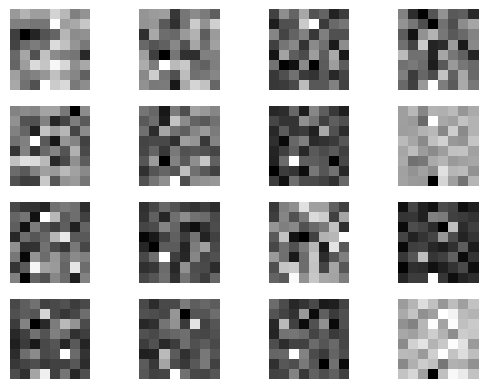

Epoch: 2, val nll=223.37404994419643


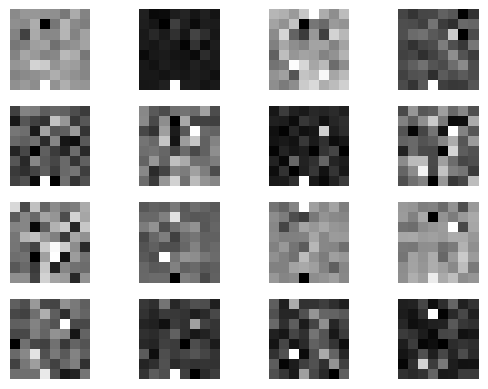

Epoch: 3, val nll=210.59388532366071


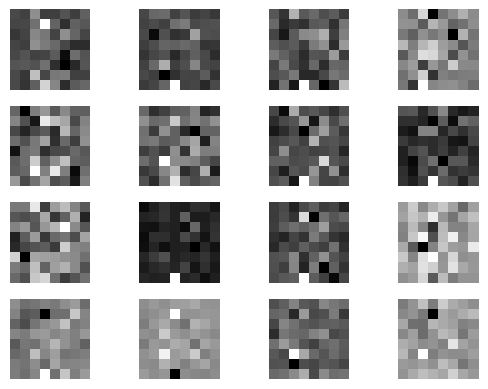

Epoch: 4, val nll=200.3403529575893


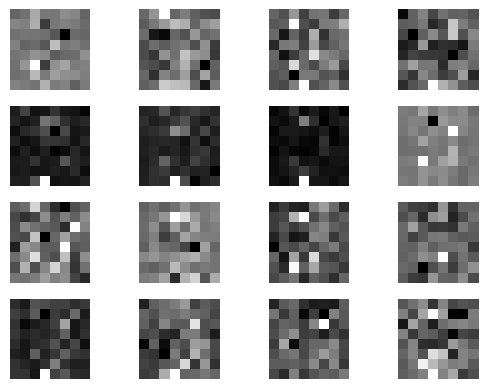

Epoch: 5, val nll=192.36206333705357


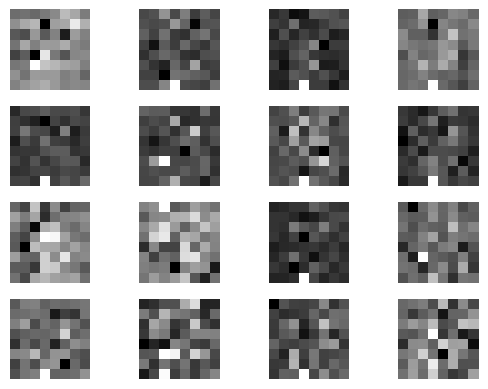

Epoch: 6, val nll=185.86600306919644


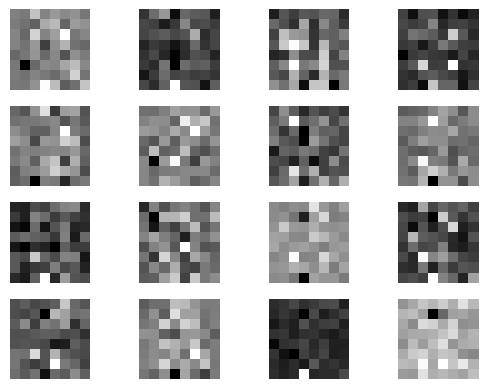

Epoch: 7, val nll=181.11666015625


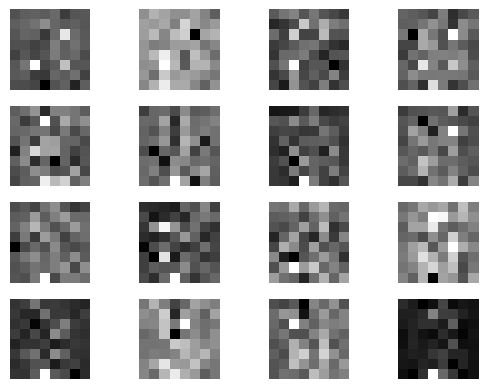

Epoch: 8, val nll=177.8400892857143


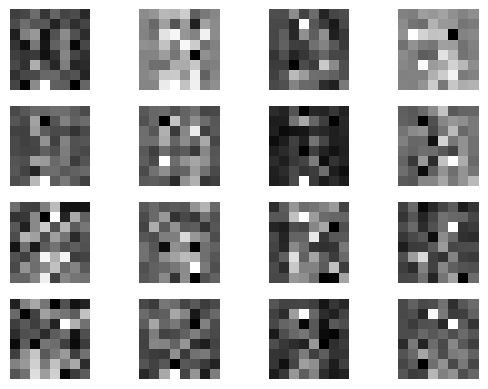

Epoch: 9, val nll=175.35914620535715


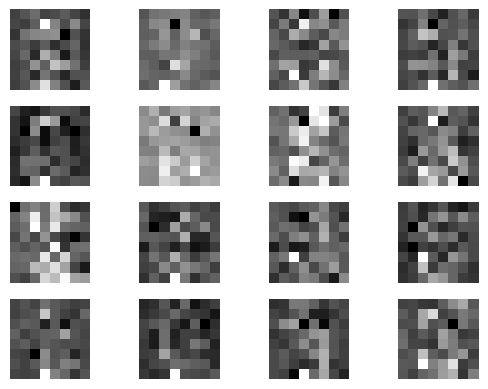

Epoch: 10, val nll=172.89447963169644


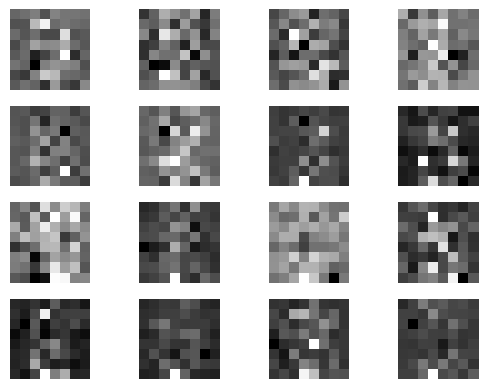

Epoch: 11, val nll=171.326455078125


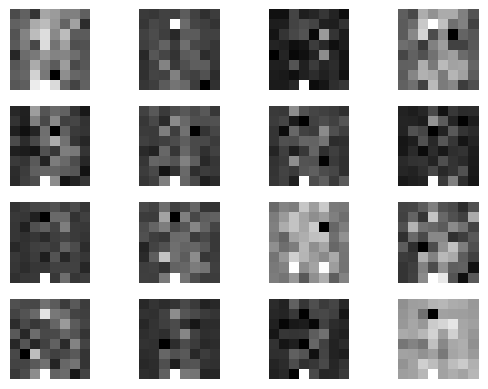

Epoch: 12, val nll=170.04615373883928


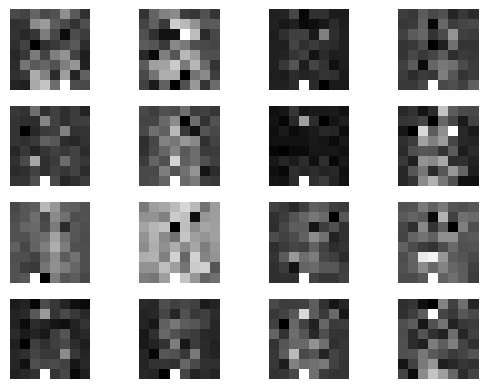

Epoch: 13, val nll=168.530146484375


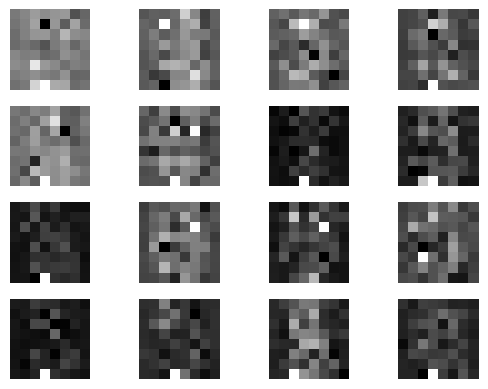

Epoch: 14, val nll=167.61919642857143


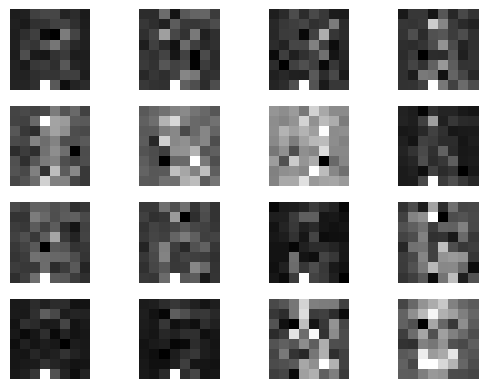

Epoch: 15, val nll=166.79172293526787


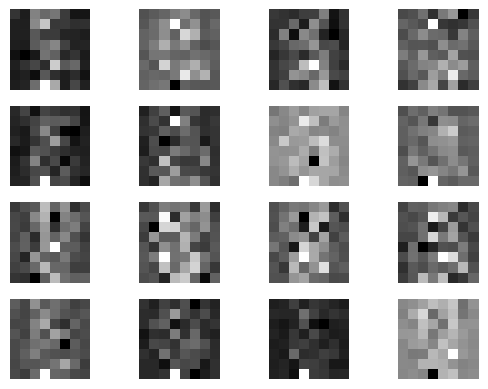

Epoch: 16, val nll=165.8791196986607


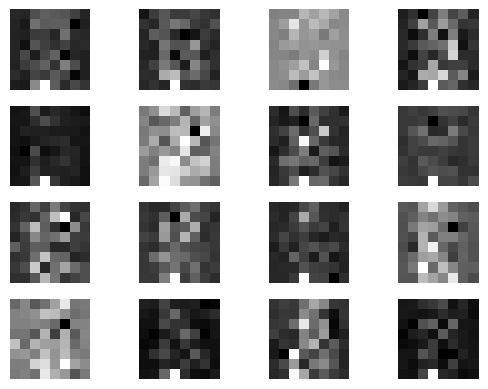

Epoch: 17, val nll=165.1852064732143


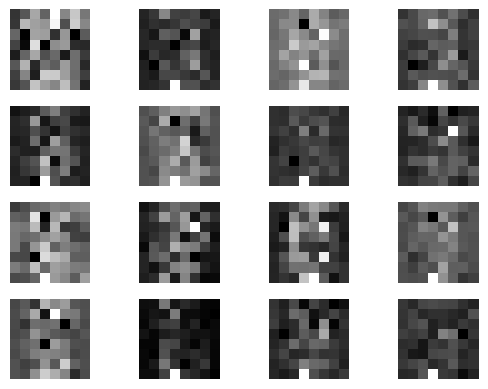

Epoch: 18, val nll=164.20416573660714


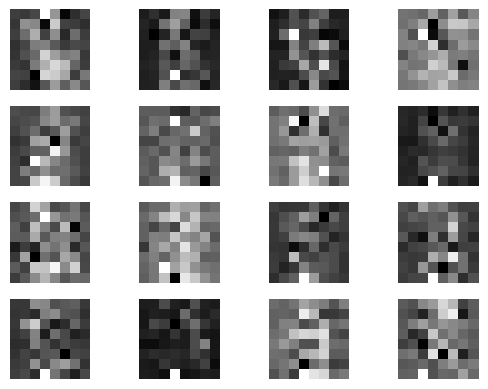

Epoch: 19, val nll=164.03211774553571


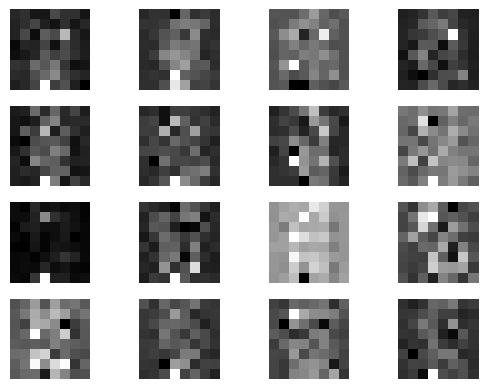

Epoch: 20, val nll=162.75565708705358


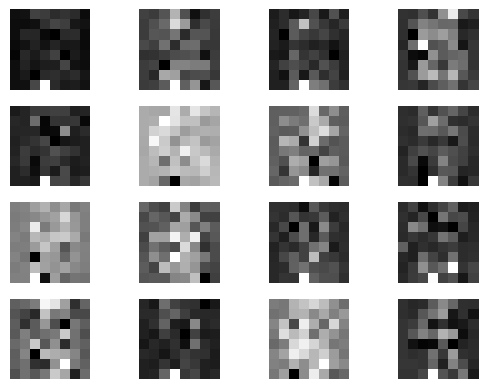

Epoch: 21, val nll=162.53408482142856


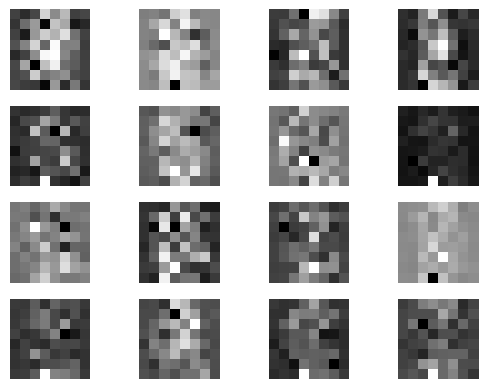

Epoch: 22, val nll=161.98532366071427


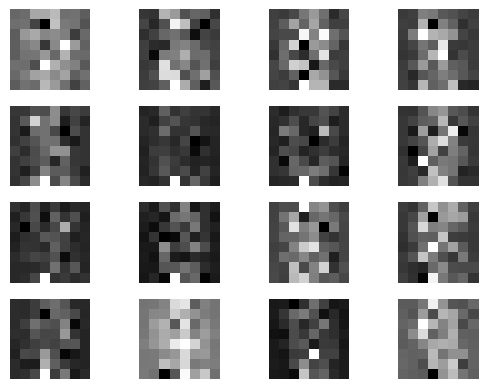

Epoch: 23, val nll=160.8088169642857


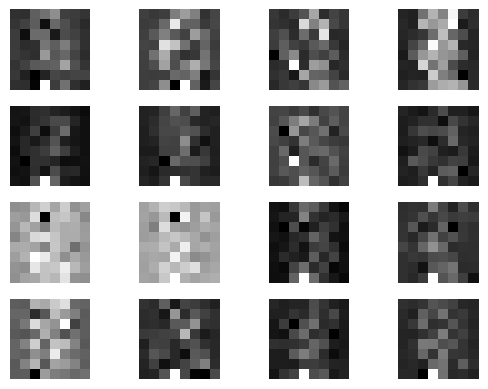

Epoch: 24, val nll=160.12042550223214


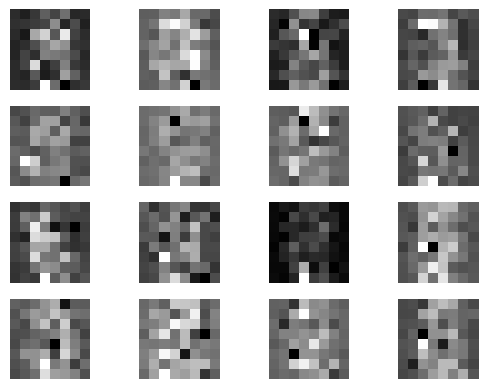

Epoch: 25, val nll=159.83862723214287


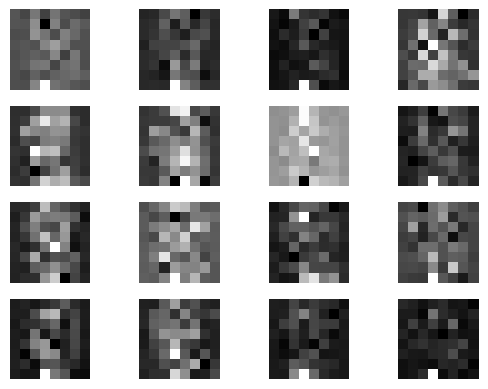

Epoch: 26, val nll=159.244755859375


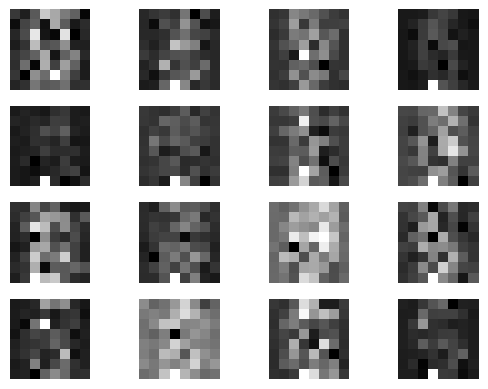

Epoch: 27, val nll=158.4228529575893


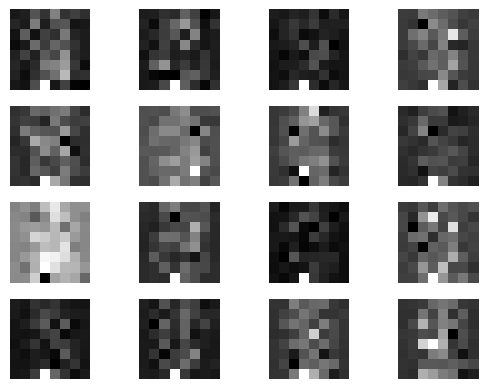

Epoch: 28, val nll=157.65034737723215


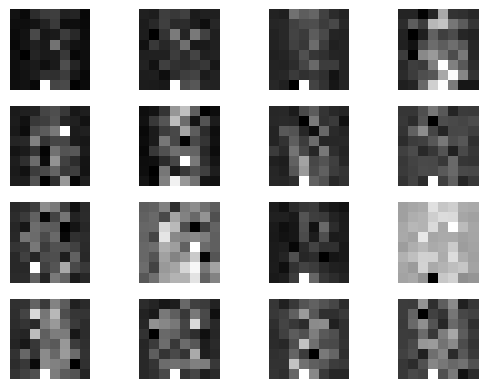

Epoch: 29, val nll=157.71601981026785
Epoch: 30, val nll=156.50206891741072


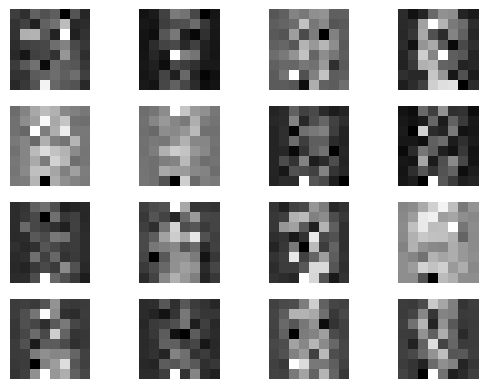

Epoch: 31, val nll=156.91911411830358
Epoch: 32, val nll=155.54096958705358


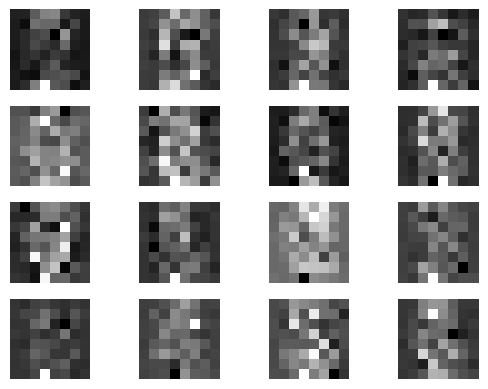

Epoch: 33, val nll=154.82725446428572


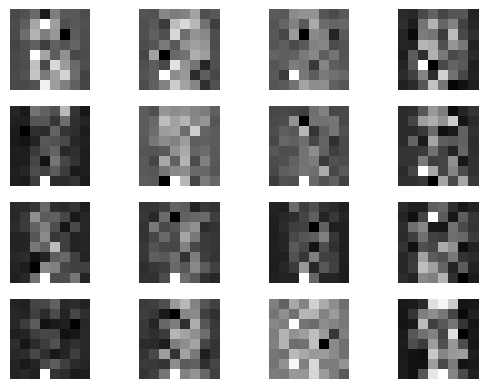

Epoch: 34, val nll=155.4833482142857
Epoch: 35, val nll=155.045869140625
Epoch: 36, val nll=153.94760323660714


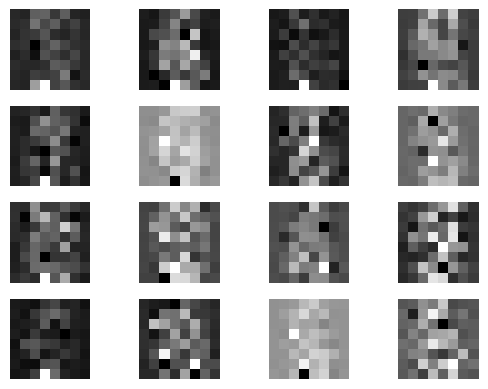

Epoch: 37, val nll=154.1256724330357
Epoch: 38, val nll=153.49336774553572


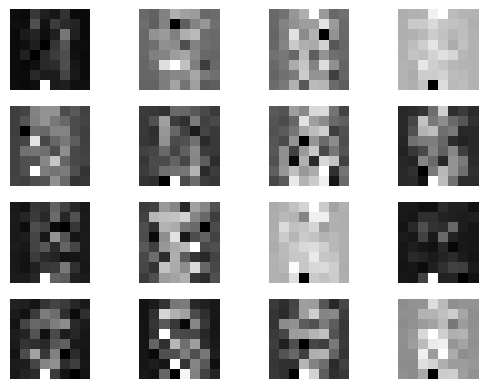

Epoch: 39, val nll=151.92513532366073


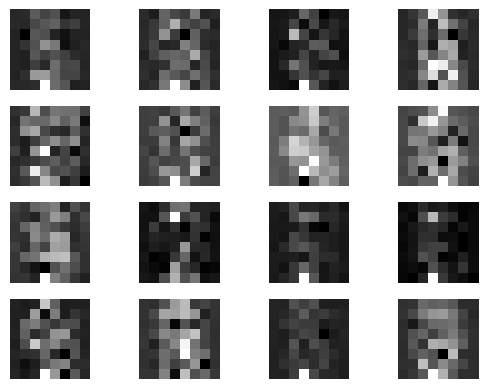

Epoch: 40, val nll=151.68865513392856


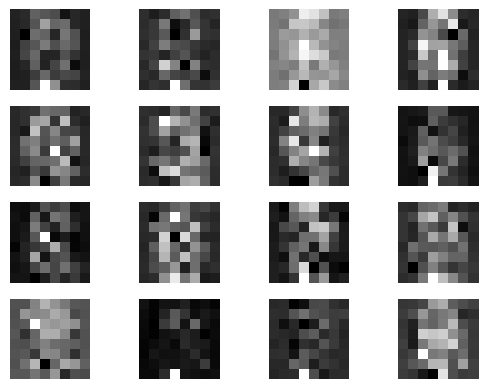

Epoch: 41, val nll=153.036494140625
Epoch: 42, val nll=150.73288783482144


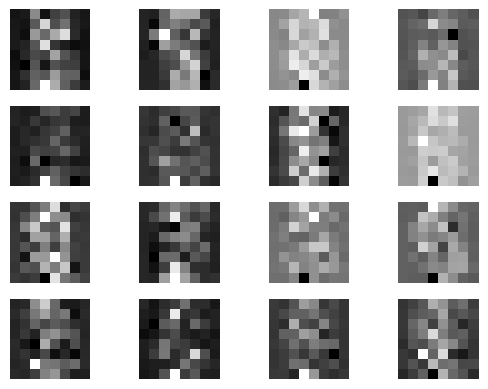

Epoch: 43, val nll=152.42777064732144
Epoch: 44, val nll=151.44028459821428
Epoch: 45, val nll=150.70159877232143


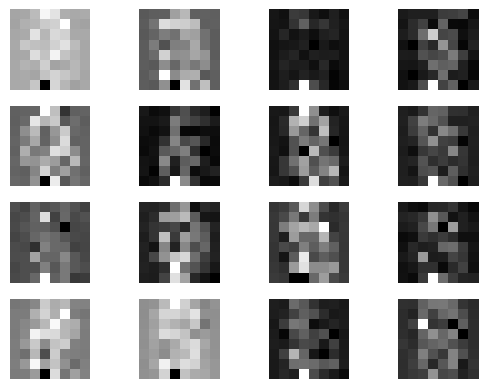

Epoch: 46, val nll=150.56183872767858


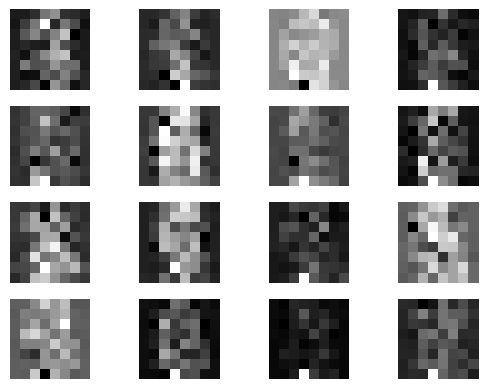

Epoch: 47, val nll=149.359609375


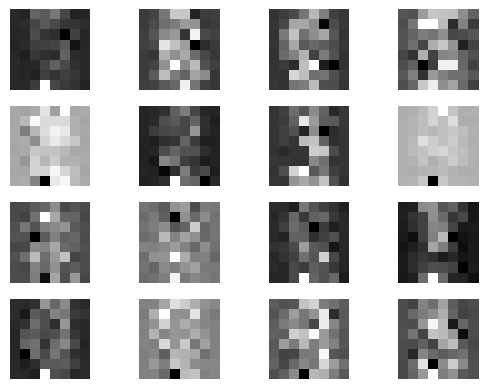

Epoch: 48, val nll=149.78375418526787
Epoch: 49, val nll=149.81654854910715
Epoch: 50, val nll=150.29131696428573
Epoch: 51, val nll=150.0928041294643
Epoch: 52, val nll=149.51667550223215
Epoch: 53, val nll=148.7770786830357


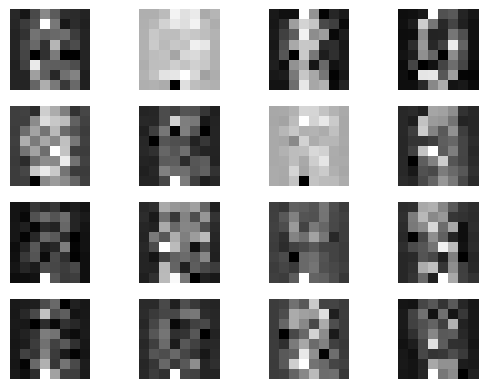

Epoch: 54, val nll=148.78769949776785
Epoch: 55, val nll=148.37337332589286


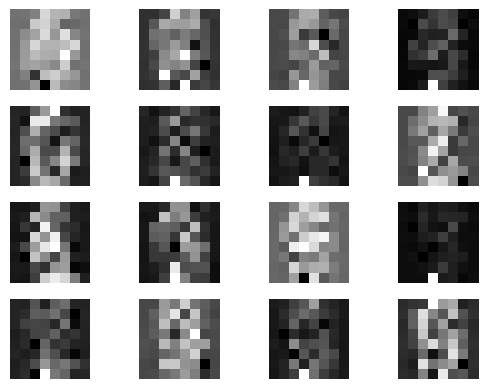

Epoch: 56, val nll=149.22481305803572
Epoch: 57, val nll=149.17312360491073
Epoch: 58, val nll=149.12452566964285
Epoch: 59, val nll=147.38562779017857


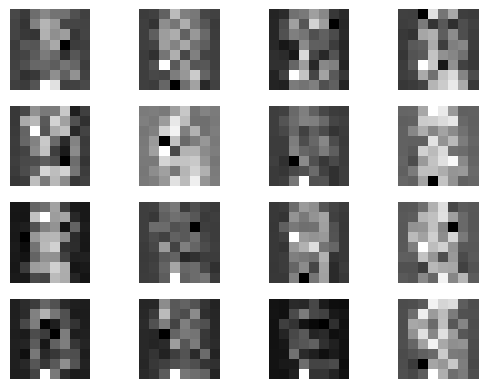

Epoch: 60, val nll=148.00737165178572
Epoch: 61, val nll=148.24589564732142
Epoch: 62, val nll=146.3501060267857


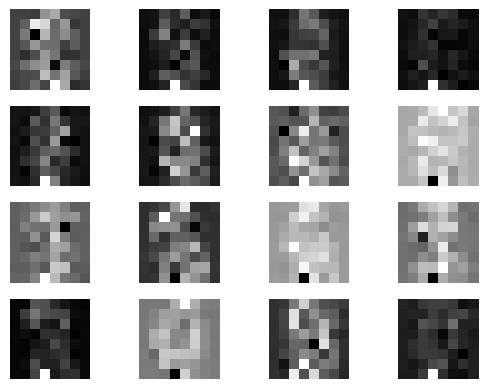

Epoch: 63, val nll=146.59767020089285
Epoch: 64, val nll=147.198486328125
Epoch: 65, val nll=147.32212611607142
Epoch: 66, val nll=146.21155552455357


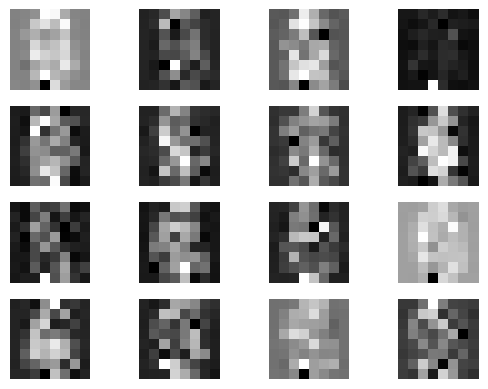

Epoch: 67, val nll=147.04290597098213
Epoch: 68, val nll=148.0244447544643
Epoch: 69, val nll=145.47223214285714


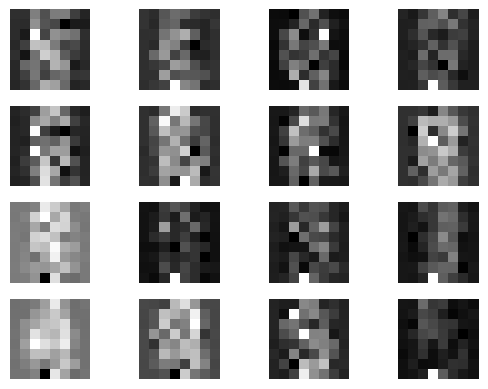

Epoch: 70, val nll=146.5552650669643
Epoch: 71, val nll=145.83011858258928
Epoch: 72, val nll=145.8896693638393
Epoch: 73, val nll=144.19233677455358


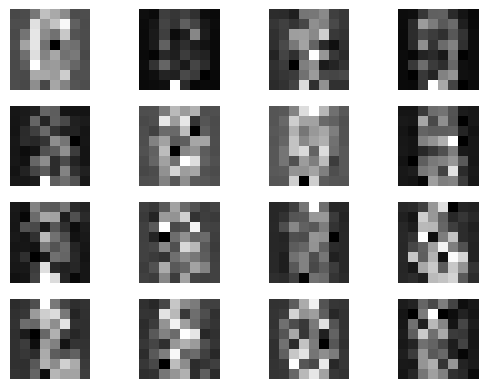

Epoch: 74, val nll=144.64915318080358
Epoch: 75, val nll=143.17577566964286


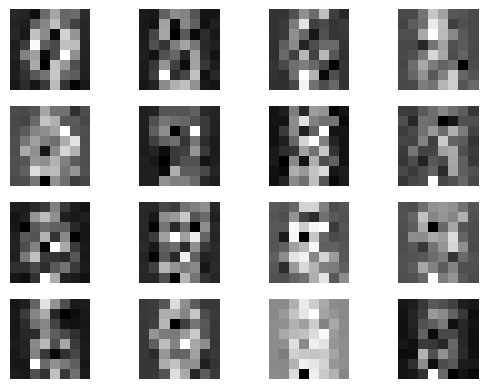

Epoch: 76, val nll=144.7903627232143
Epoch: 77, val nll=144.78298270089286
Epoch: 78, val nll=142.46295340401787


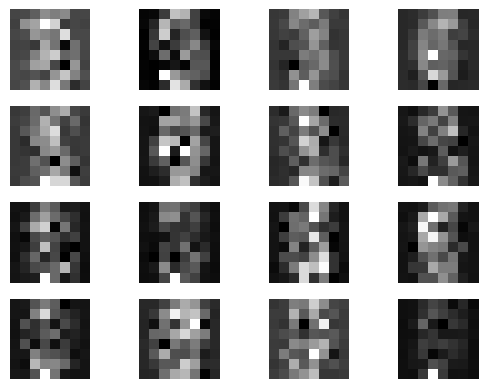

Epoch: 79, val nll=141.76855887276787


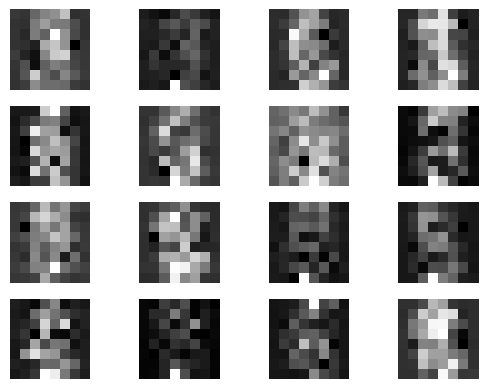

Epoch: 80, val nll=144.63838169642858
Epoch: 81, val nll=144.26630440848214
Epoch: 82, val nll=143.71664481026787
Epoch: 83, val nll=141.31226981026785


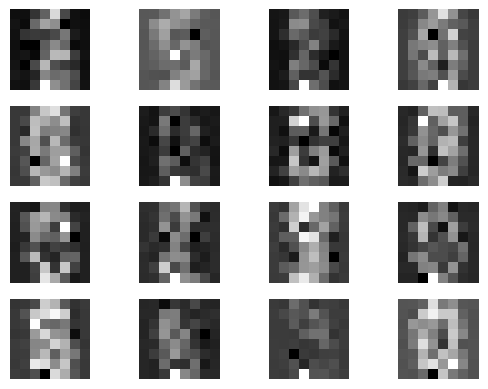

Epoch: 84, val nll=142.40642159598215
Epoch: 85, val nll=143.94831752232142
Epoch: 86, val nll=140.2346484375


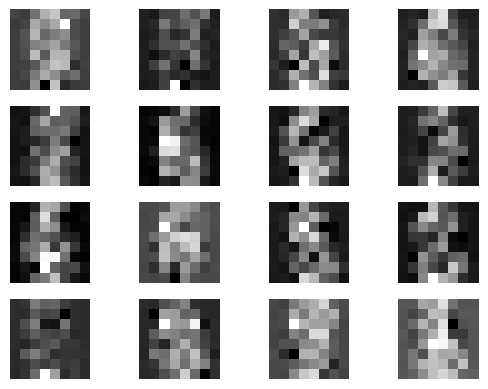

Epoch: 87, val nll=140.93607979910715
Epoch: 88, val nll=142.8751953125
Epoch: 89, val nll=141.21940987723215
Epoch: 90, val nll=141.08179966517858
Epoch: 91, val nll=140.90147181919642
Epoch: 92, val nll=141.33827845982142
Epoch: 93, val nll=141.03233119419642
Epoch: 94, val nll=141.51170340401785
Epoch: 95, val nll=141.484580078125
Epoch: 96, val nll=140.61826590401785
Epoch: 97, val nll=139.67803152901786


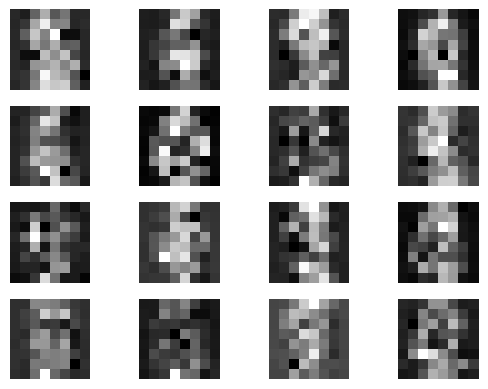

Epoch: 98, val nll=141.12983537946428
Epoch: 99, val nll=140.27494977678572
Epoch: 100, val nll=141.01967633928572
Epoch: 101, val nll=145.02189592633928
Epoch: 102, val nll=136.91649135044642


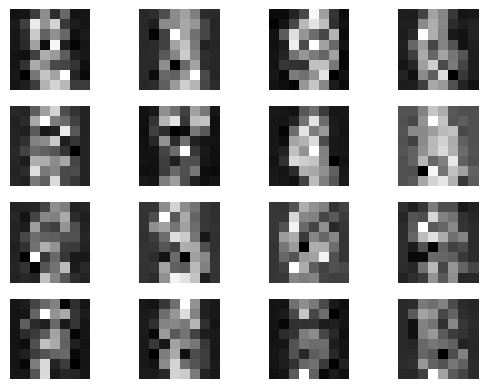

Epoch: 103, val nll=138.22479910714284
Epoch: 104, val nll=141.68388113839285
Epoch: 105, val nll=137.9839467075893
Epoch: 106, val nll=139.74125697544642
Epoch: 107, val nll=139.61374720982144
Epoch: 108, val nll=139.00612025669642
Epoch: 109, val nll=142.73681640625
Epoch: 110, val nll=138.42708565848216
Epoch: 111, val nll=138.12035574776786
Epoch: 112, val nll=140.8325181361607
Epoch: 113, val nll=139.60933035714285
Epoch: 114, val nll=139.68042689732144
Epoch: 115, val nll=139.904091796875
Epoch: 116, val nll=136.88179966517856


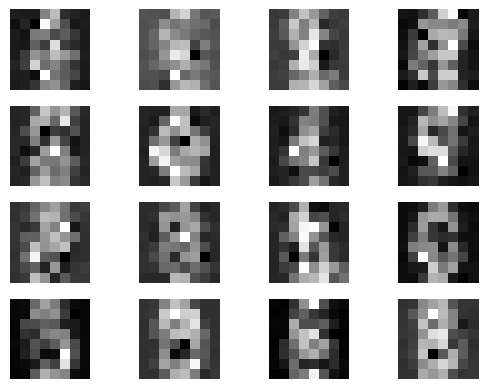

Epoch: 117, val nll=138.09532366071429
Epoch: 118, val nll=138.29017578125
Epoch: 119, val nll=137.60765904017856
Epoch: 120, val nll=138.44876674107144
Epoch: 121, val nll=140.11827706473215
Epoch: 122, val nll=136.39215959821428


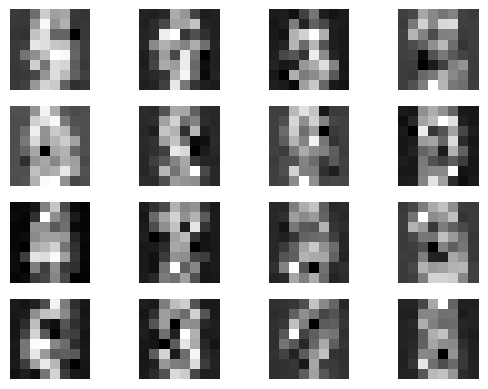

Epoch: 123, val nll=137.93034877232142
Epoch: 124, val nll=137.22512137276786
Epoch: 125, val nll=135.8732407924107


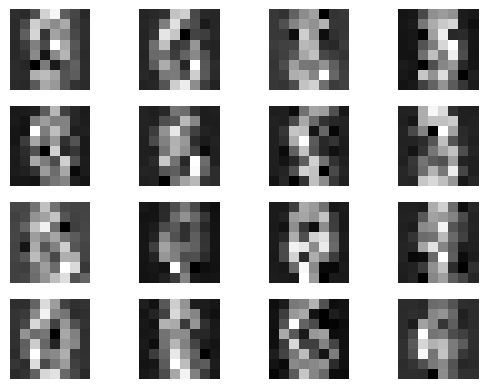

Epoch: 126, val nll=136.61921456473215
Epoch: 127, val nll=135.49181919642857


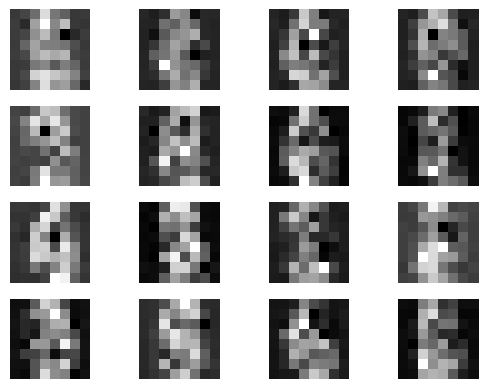

Epoch: 128, val nll=139.25537388392857
Epoch: 129, val nll=136.81279994419643
Epoch: 130, val nll=134.06723772321428


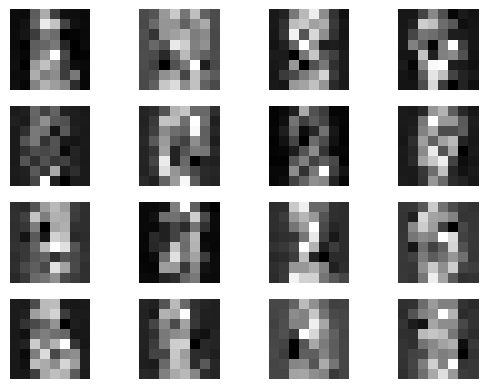

Epoch: 131, val nll=136.25877650669642
Epoch: 132, val nll=135.70597377232144
Epoch: 133, val nll=136.317958984375
Epoch: 134, val nll=135.054365234375
Epoch: 135, val nll=135.59135323660715
Epoch: 136, val nll=135.131142578125
Epoch: 137, val nll=134.30992047991072
Epoch: 138, val nll=135.69073660714287
Epoch: 139, val nll=135.15434430803572
Epoch: 140, val nll=136.43111607142856
Epoch: 141, val nll=136.16260323660714
Epoch: 142, val nll=134.8767103794643
Epoch: 143, val nll=136.71553013392858
Epoch: 144, val nll=135.57780970982142
Epoch: 145, val nll=135.44170619419643
Epoch: 146, val nll=136.43364536830356
Epoch: 147, val nll=134.81738560267857
Epoch: 148, val nll=134.70547293526786
Epoch: 149, val nll=133.53406529017857


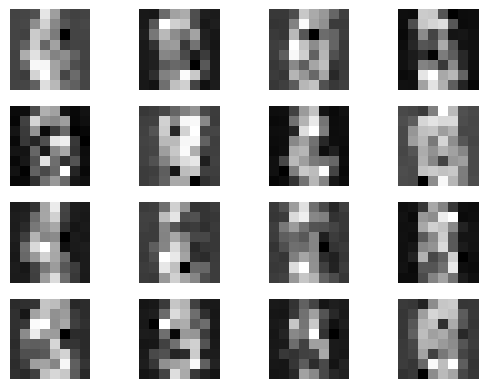

Epoch: 150, val nll=134.91994140625
Epoch: 151, val nll=135.83853097098213
Epoch: 152, val nll=133.52353236607144


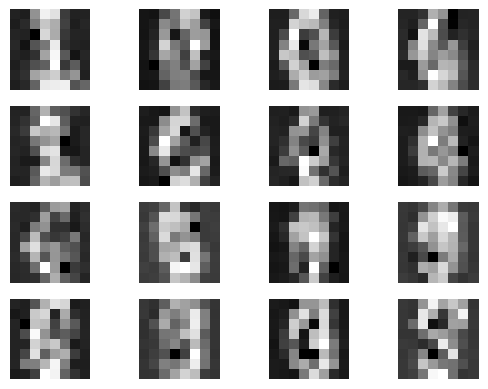

Epoch: 153, val nll=133.34679268973215


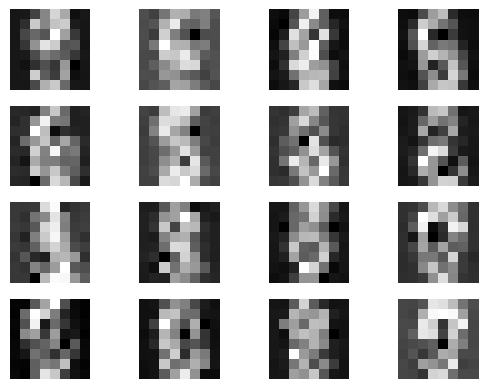

Epoch: 154, val nll=136.08927315848214
Epoch: 155, val nll=135.8317494419643
Epoch: 156, val nll=138.11765764508928
Epoch: 157, val nll=135.68521763392857
Epoch: 158, val nll=136.82165597098214
Epoch: 159, val nll=133.55284737723215
Epoch: 160, val nll=135.89815150669642
Epoch: 161, val nll=137.332177734375
Epoch: 162, val nll=134.71510463169642
Epoch: 163, val nll=134.07207449776786
Epoch: 164, val nll=138.30567522321428
Epoch: 165, val nll=135.13389369419642
Epoch: 166, val nll=136.42782924107144
Epoch: 167, val nll=136.22536411830356
Epoch: 168, val nll=136.31152064732143
Epoch: 169, val nll=136.22950474330358
Epoch: 170, val nll=135.79943080357143
Epoch: 171, val nll=136.063193359375
Epoch: 172, val nll=137.58451171875
Epoch: 173, val nll=135.94511439732142
Epoch: 174, val nll=135.75071568080358


In [10]:
# Training procedure
nll_val = training(name=None, max_patience=max_patience, num_epochs=num_epochs, model=model, optimizer=optimizer,
                       training_loader=training_loader, val_loader=val_loader)

FINAL LOSS: nll=119.43648302048378
Test loss: 119.43648302048378


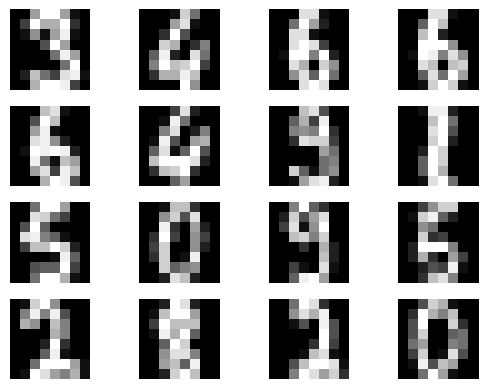

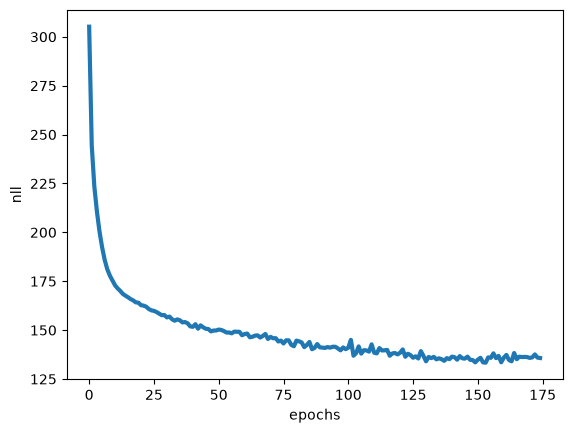

In [11]:
# Evaluate and display results without saving anything to disk
test_loss = evaluation(model_best=model, test_loader=test_loader)
print(f'Test loss: {test_loss}')

samples_real(test_loader)
plot_curve(nll_val)